Import Libraries

In [1]:
import os
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs("../models", exist_ok=True)
os.makedirs("../figures", exist_ok=True)
os.makedirs("../results", exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("Setup completed successfully.")

TensorFlow version: 2.21.0
Setup completed successfully.


Check GPU availability

In [2]:
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU detected:", gpus)
else:
    print("No GPU detected. Training will use the CPU.")

No GPU detected. Training will use the CPU.


Load preprocessed binary data (train/val/test, using the validation split already prepared in Preprocessing.ipynb)

In [3]:
X_train_final = np.load("../results/X_train_binary.npy").astype("float32")
X_val = np.load("../results/X_val_binary.npy").astype("float32")
X_test = np.load("../results/X_test_binary.npy").astype("float32")

y_train_final = np.load("../results/y_train_binary.npy").astype("float32")
y_val = np.load("../results/y_val_binary.npy").astype("float32")
y_test = np.load("../results/y_test_binary.npy").astype("float32")

print("Training set  :", X_train_final.shape)
print("Validation set:", X_val.shape)
print("Testing set   :", X_test.shape)


Training set  : (65865, 190)
Validation set: (16467, 190)
Testing set   : (175341, 190)


Examine class distribution

In [4]:
def class_distribution(labels, dataset_name):
    values, counts = np.unique(labels, return_counts=True)

    distribution = pd.DataFrame({
        "Label": values.astype(int),
        "Class": [
            "Normal" if value == 0 else "Attack"
            for value in values
        ],
        "Count": counts,
        "Percentage": np.round(counts / len(labels) * 100, 2)
    })

    print(dataset_name)
    display(distribution)


class_distribution(y_train_final, "Training distribution")
class_distribution(y_val, "Validation distribution")
class_distribution(y_test, "Testing distribution")

Training distribution


,Label,Class,Count,Percentage
0,0,Normal,29600,44.94
1,1,Attack,36265,55.06


Validation distribution


,Label,Class,Count,Percentage
0,0,Normal,7400,44.94
1,1,Attack,9067,55.06


Testing distribution


,Label,Class,Count,Percentage
0,0,Normal,56000,31.94
1,1,Attack,119341,68.06


## Build the baseline DNN

The baseline should remain simple. Do not add dropout, batch normalization, class weighting, or early stopping yet. Those will be introduced individually during optimization.

Define baseline architecture

In [5]:
input_features = X_train_final.shape[1]

baseline_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_features,)),

    tf.keras.layers.Dense(
        units=128,
        activation="relu",
        name="hidden_layer_1"
    ),

    tf.keras.layers.Dense(
        units=64,
        activation="relu",
        name="hidden_layer_2"
    ),

    tf.keras.layers.Dense(
        units=1,
        activation="sigmoid",
        name="output_layer"
    )
])

print("Baseline model created successfully.")

Baseline model created successfully.


Compile the model

In [6]:
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │        24,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,769 (128.00 KB)

 Trainable params: 32,769 (128.00 KB)

 Non-trainable params: 0 (0.00 B)

Record model parameters

In [7]:
total_parameters = baseline_model.count_params()

print("Input features:", input_features)
print("Total parameters:", f"{total_parameters:,}")

Input features: 190
Total parameters: 32,769


## Train the baseline

Training configuration

In [8]:
BASELINE_EPOCHS = 30
BATCH_SIZE = 256

print("Epochs:", BASELINE_EPOCHS)
print("Batch size:", BATCH_SIZE)

Epochs: 30
Batch size: 256


Train the model

In [9]:
start_time = time.time()

baseline_history = baseline_model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=BASELINE_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    shuffle=True
)

training_time = time.time() - start_time

print(
    f"\nBaseline training time: "
    f"{training_time:.2f} seconds"
)

Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8629 - auc: 0.9484 - loss: 0.2856 - precision: 0.8988 - recall: 0.8463 - val_accuracy: 0.9055 - val_auc: 0.9778 - val_loss: 0.2018 - val_precision: 0.9668 - val_recall: 0.8578
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9228 - auc: 0.9817 - loss: 0.1758 - precision: 0.9363 - recall: 0.9226 - val_accuracy: 0.9204 - val_auc: 0.9838 - val_loss: 0.1768 - val_precision: 0.9756 - val_recall: 0.8775
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9375 - auc: 0.9860 - loss: 0.1523 - precision: 0.9471 - recall: 0.9389 - val_accuracy: 0.9345 - val_auc: 0.9863 - val_loss: 0.1624 - val_precision: 0.9735 - val_recall: 0.9058
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9433 - auc: 0.9877 - loss: 0.1410 - precision: 0.9516 - recall: 0.9450 - val_accuracy: 0.9426 - val_auc: 0.9877 - val_loss: 0.1519 - val_precision: 0.9730 - val_recall: 0.9214
Epoch 5/30
258/258 ━━━━━━━━━━━━━

## Visualize training history

Accuracy curve

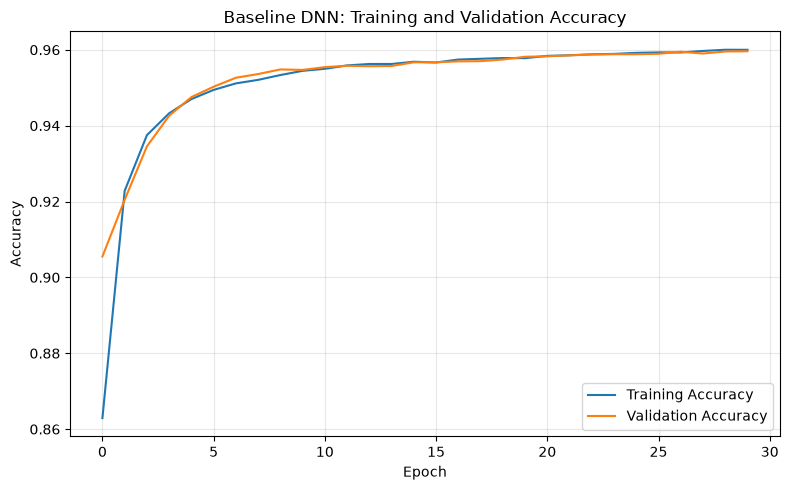

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    baseline_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Baseline DNN: Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../figures/baseline_binary_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Loss curve

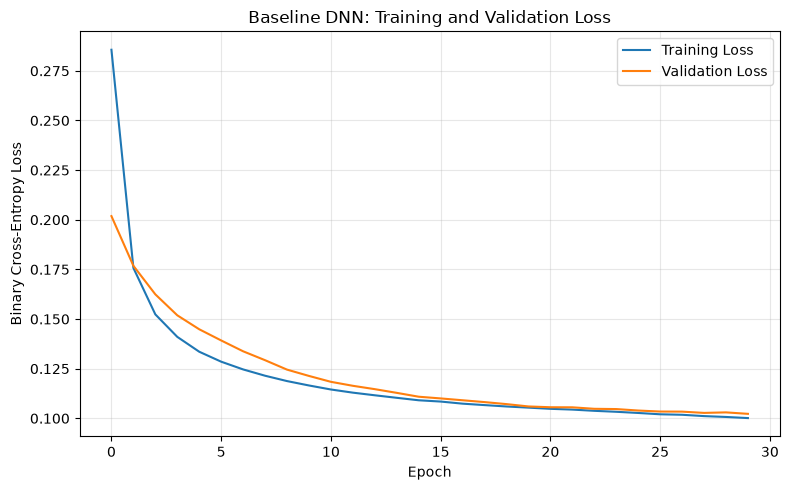

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    baseline_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Baseline DNN: Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../figures/baseline_binary_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Precision and recall curves

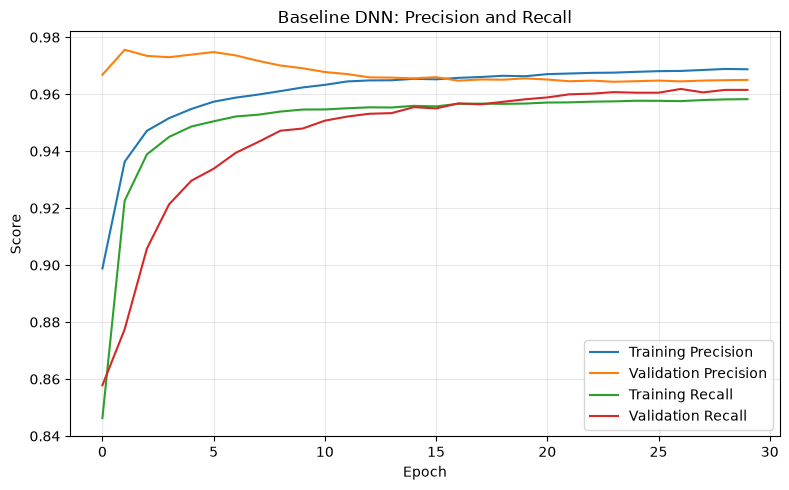

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["precision"],
    label="Training Precision"
)

plt.plot(
    baseline_history.history["val_precision"],
    label="Validation Precision"
)

plt.plot(
    baseline_history.history["recall"],
    label="Training Recall"
)

plt.plot(
    baseline_history.history["val_recall"],
    label="Validation Recall"
)

plt.title("Baseline DNN: Precision and Recall")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../figures/baseline_binary_precision_recall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Evaluate on the test set

Keras test evaluation

In [13]:
test_results = baseline_model.evaluate(
    X_test,
    y_test,
    verbose=0,
    return_dict=True
)

print("Keras test results:")

for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

Keras test results:
accuracy: 0.8923
auc: 0.9821
loss: 0.2856
precision: 0.9866
recall: 0.8533


Generate predictions

In [14]:
y_probability = baseline_model.predict(
    X_test,
    batch_size=BATCH_SIZE,
    verbose=1
).ravel()

y_prediction = (y_probability >= 0.5).astype(int)

print("Probabilities shape:", y_probability.shape)
print("Predictions shape:", y_prediction.shape)
print("Unique predictions:", np.unique(y_prediction))

685/685 ━━━━━━━━━━━━━━━━━━━━ 0s 536us/step
Probabilities shape: (175341,)
Predictions shape: (175341,)
Unique predictions: [0 1]


Calculate final metrics

In [15]:
baseline_accuracy = accuracy_score(
    y_test,
    y_prediction
)

baseline_precision = precision_score(
    y_test,
    y_prediction,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    y_prediction,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    y_prediction,
    zero_division=0
)

baseline_auc = roc_auc_score(
    y_test,
    y_probability
)

print(f"Test Accuracy : {baseline_accuracy:.4f}")
print(f"Test Precision: {baseline_precision:.4f}")
print(f"Test Recall   : {baseline_recall:.4f}")
print(f"Test F1-score : {baseline_f1:.4f}")
print(f"Test ROC-AUC  : {baseline_auc:.4f}")


Test Accuracy : 0.8923
Test Precision: 0.9866
Test Recall   : 0.8533
Test F1-score : 0.9151
Test ROC-AUC  : 0.9837


Classification report

In [16]:
classification_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_prediction,
        target_names=["Normal", "Attack"],
        output_dict=True,
        zero_division=0
    )
).transpose()

classification_report_df

,precision,recall,f1-score,support
Normal,0.757275,0.975357,0.852592,56000.000000
Attack,0.986630,0.853303,0.915136,119341.000000
accuracy,0.892284,0.892284,0.892284,0.892284
macro avg,0.871953,0.914330,0.883864,175341.000000
weighted avg,0.913379,0.892284,0.895160,175341.000000


Confusion matrix

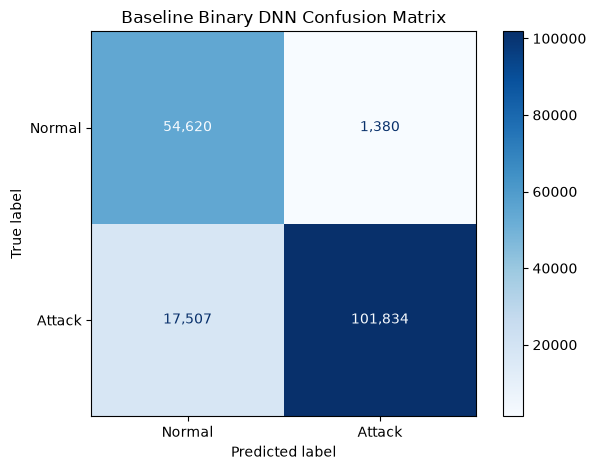

In [17]:
confusion = confusion_matrix(
    y_test,
    y_prediction
)

display_confusion = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["Normal", "Attack"]
)

display_confusion.plot(
    values_format=",",
    cmap="Blues"
)

plt.title("Baseline Binary DNN Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../figures/baseline_binary_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ROC curve

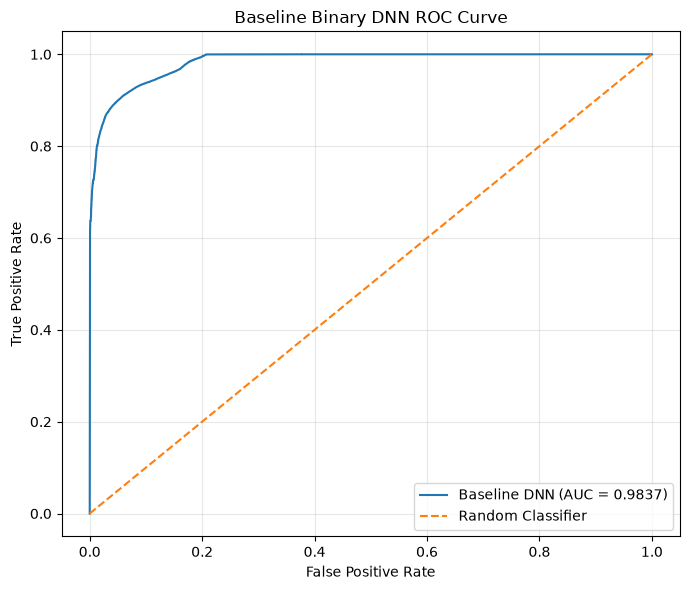

In [18]:
false_positive_rate, true_positive_rate, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 6))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"Baseline DNN (AUC = {baseline_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("Baseline Binary DNN ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../figures/baseline_binary_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Save baseline outputs

Save training history

In [19]:
history_df = pd.DataFrame(
    baseline_history.history
)

history_df.index = history_df.index + 1
history_df.index.name = "Epoch"

history_df.to_csv(
    "../results/baseline_binary_history.csv"
)

history_df.head()

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall
Epoch,,,,,,,,,,
1,0.862917,0.948355,0.285622,0.898817,0.846298,0.905508,0.977808,0.201834,0.966812,0.857836
2,0.922812,0.981670,0.175759,0.936281,0.922598,0.920447,0.983828,0.176815,0.975598,0.877468
3,0.937493,0.985973,0.152349,0.947146,0.938867,0.934536,0.986270,0.162440,0.973450,0.905812
4,0.943263,0.987734,0.141026,0.951602,0.945016,0.942612,0.987729,0.151887,0.972979,0.921363
5,0.947013,0.988730,0.133540,0.954817,0.948656,0.947531,0.988391,0.144849,0.973888,0.929635


Save classification report

In [20]:
classification_report_df.to_csv(
    "../results/baseline_binary_classification_report.csv"
)

print("Classification report saved.")

Classification report saved.


Save experiment summary

In [21]:
baseline_results = pd.DataFrame([{
    "Experiment": "Binary Baseline",
    "Hidden Layers": 2,
    "Architecture": "128-64-1",
    "Activation": "ReLU",
    "Output Activation": "Sigmoid",
    "Optimizer": "Adam",
    "Learning Rate": 0.001,
    "Batch Size": BATCH_SIZE,
    "Epochs": BASELINE_EPOCHS,
    "Dropout": 0.0,
    "Batch Normalization": False,
    "Class Weights": False,
    "Early Stopping": False,
    "Parameters": total_parameters,
    "Test Accuracy": baseline_accuracy,
    "Test Precision": baseline_precision,
    "Test Recall": baseline_recall,
    "Test F1": baseline_f1,
    "Test ROC-AUC": baseline_auc,
    "Training Time Seconds": training_time
}])

baseline_results.to_csv(
    "../results/binary_experiment_results.csv",
    index=False
)

baseline_results

,Experiment,Hidden Layers,Architecture,Activation,Output Activation,Optimizer,Learning Rate,Batch Size,Epochs,Dropout,Batch Normalization,Class Weights,Early Stopping,Parameters,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Training Time Seconds
0,Binary Baseline,2,128-64-1,ReLU,Sigmoid,Adam,0.001,256,30,0.0,False,False,False,32769,0.892284,0.98663,0.853303,0.915136,0.983712,11.594687


Save the trained mode

In [22]:
baseline_model.save(
    "../models/binary_baseline.keras"
)

print("Baseline model saved successfully.")

Baseline model saved successfully.


Final summary

In [23]:
print("=" * 60)
print("BINARY BASELINE EXPERIMENT COMPLETED")
print("=" * 60)

print(f"Architecture       : 128 → 64 → 1")
print(f"Parameters         : {total_parameters:,}")
print(f"Training time      : {training_time:.2f} seconds")
print(f"Test accuracy      : {baseline_accuracy:.4f}")
print(f"Test precision     : {baseline_precision:.4f}")
print(f"Test recall        : {baseline_recall:.4f}")
print(f"Test F1-score      : {baseline_f1:.4f}")
print(f"Test ROC-AUC       : {baseline_auc:.4f}")

print("\nSaved model:")
print("../models/binary_baseline.keras")

print("\nSaved results:")
print("../results/binary_experiment_results.csv")
print("../results/baseline_binary_history.csv")

print("\nSaved figures:")
print("../figures/baseline_binary_accuracy.png")
print("../figures/baseline_binary_loss.png")
print("../figures/baseline_binary_confusion_matrix.png")
print("../figures/baseline_binary_roc_curve.png")

BINARY BASELINE EXPERIMENT COMPLETED
Architecture       : 128 → 64 → 1
Parameters         : 32,769
Training time      : 11.59 seconds
Test accuracy      : 0.8923
Test precision     : 0.9866
Test recall        : 0.8533
Test F1-score      : 0.9151
Test ROC-AUC       : 0.9837

Saved model:
../models/binary_baseline.keras

Saved results:
../results/binary_experiment_results.csv
../results/baseline_binary_history.csv

Saved figures:
../figures/baseline_binary_accuracy.png
../figures/baseline_binary_loss.png
../figures/baseline_binary_confusion_matrix.png
../figures/baseline_binary_roc_curve.png
